In [ ]:
# %pip install pandas numpy seaborn matplotlib

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/train.csv')

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [ ]:
df.shape

(891, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
# Missing Value Percentage
df.isnull().sum()/df.shape[0]*100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [ ]:
# finding duplicates
df.duplicated().sum()

0

Drop Cabin
missing Embarked, Age

In [ ]:
for i in df.select_dtypes(include="object").columns:
	print(df[i].value_counts())
	print("***"*10)

Name
Braund, Mr. Owen Harris                     1
Boulos, Mr. Hanna                           1
Frolicher-Stehli, Mr. Maxmillian            1
Gilinski, Mr. Eliezer                       1
Murdlin, Mr. Joseph                         1
                                           ..
Kelly, Miss. Anna Katherine "Annie Kate"    1
McCoy, Mr. Bernard                          1
Johnson, Mr. William Cahoone Jr             1
Keane, Miss. Nora A                         1
Dooley, Mr. Patrick                         1
Name: count, Length: 891, dtype: int64
******************************
Sex
male      577
female    314
Name: count, dtype: int64
******************************
Ticket
347082      7
CA. 2343    7
1601        7
3101295     6
CA 2144     6
           ..
9234        1
19988       1
2693        1
PC 17612    1
370376      1
Name: count, Length: 681, dtype: int64
******************************
Cabin
B96 B98        4
G6             4
C23 C25 C27    4
C22 C26        3
F33            3
        

In [ ]:
# Count, Unique, Top, Frequency dari Data Object
df.describe(include="object")

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


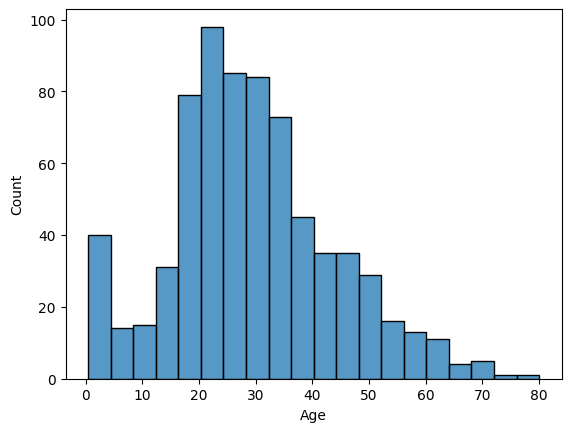

In [ ]:
for i in ['Age']:
	sns.histplot(data=df, x=i)
	plt.show()

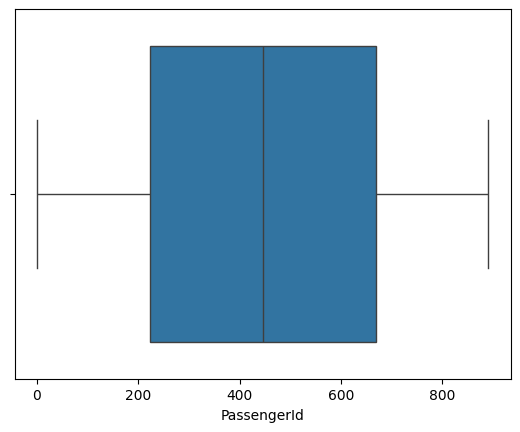

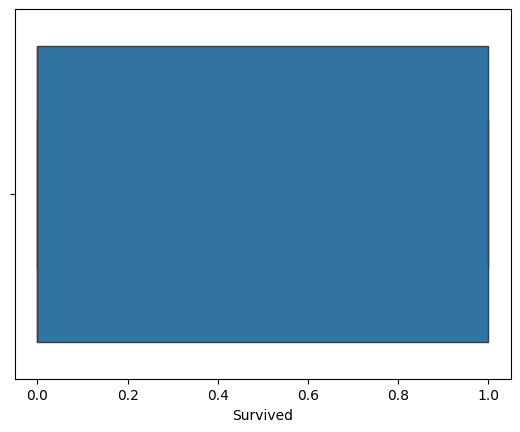

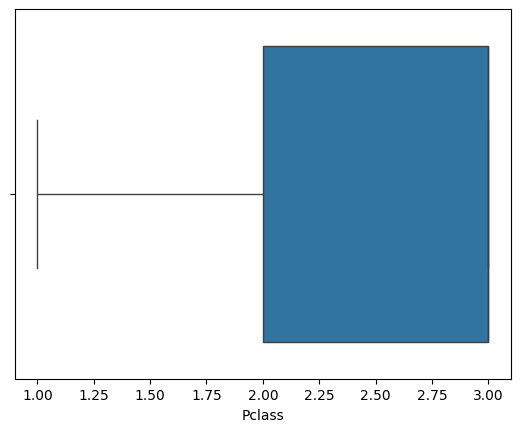

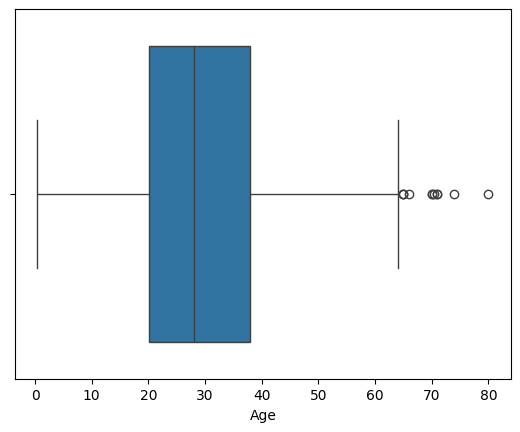

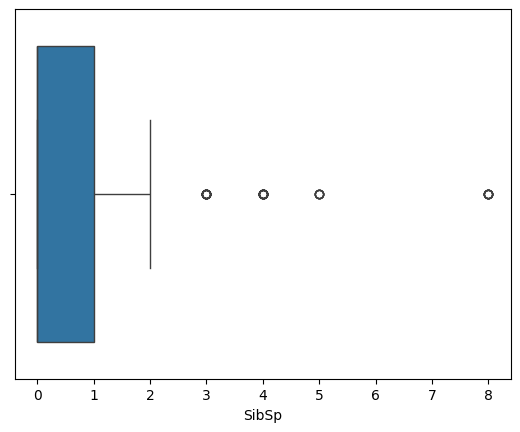

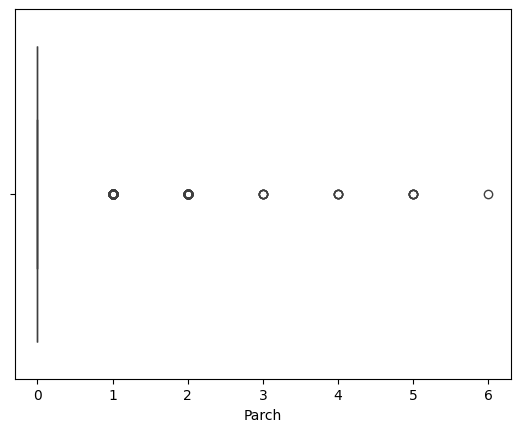

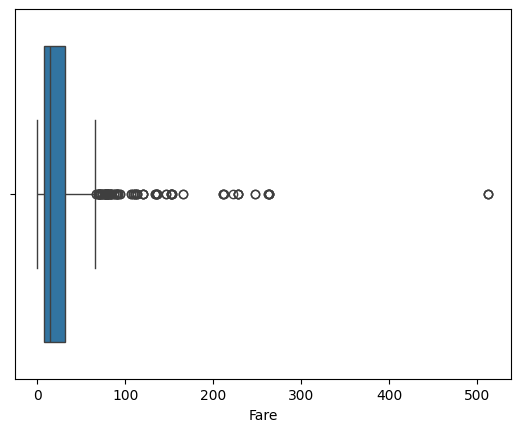

In [ ]:
for i in df.select_dtypes(include="number").columns:
	sns.boxplot(data=df, x=i)
	plt.show()

<Axes: >

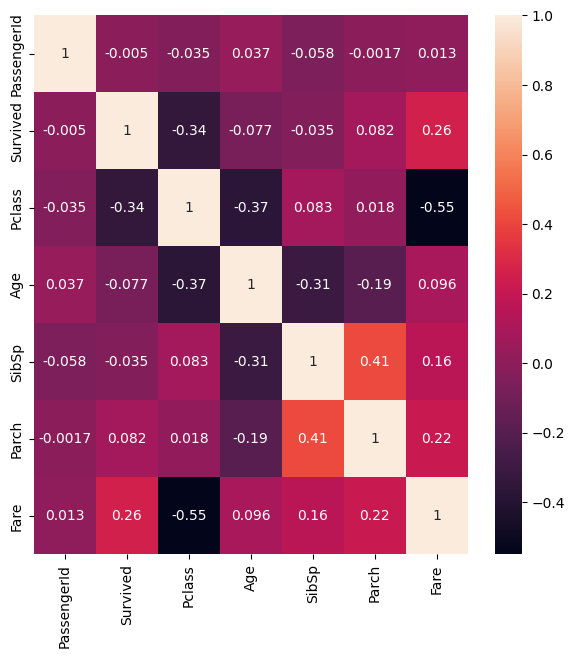

In [ ]:
s = df.select_dtypes(include="number").corr()

# Heatmap
plt.figure(figsize=(7,7))
sns.heatmap(s, annot=True)

In [ ]:
df = df.drop('Cabin', axis=1)

# Kalau distribusi tidak normal (Median)
for i in ["Age"]:
	df[i].fillna(df[i].median(), inplace=True)

for i in ['Embarked']:
	df[i].fillna(df[i].mode()[0], inplace=True)

/tmp/ipykernel_123447/3478082369.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[i].fillna(df[i].median(), inplace=True)
/tmp/ipykernel_123447/3478082369.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [ ]:
# Outlier Handling
df['Fare'] = df['Fare'].map(lambda x: np.log1p(x))

In [ ]:
dummy = pd.get_dummies(data = df, columns = ["Pclass" ,"Sex", "Embarked"], drop_first=True)
df = dummy.drop(['PassengerId', 'Name', 'Ticket'], axis=1)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

X = df.drop('Survived', axis=1)
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# Buat model
model_nb = GaussianNB()
model_nb.fit(X_train, y_train)

# Membuat Prediksi
y_pred = model_nb.predict(X_test)
# Membuat Prediksi Probabilitas untuk ROC-AUC
y_proba = model_nb.predict_proba(X_test)[:, 1]

print("Hasil Evaluasi Naive Bayes\n")
TN, FP, FN, TP = confusion_matrix(y_test, y_pred).ravel()
# 1. Akurasi (Accuracy)
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi Model: {(TP+TN)/(TP+TN+FP+FN)}")

# 2. Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# 3. Precision, Recall, F1-Score (dari Classification Report)
print("\nClassification Report:")
print("Precision: {:.4f}".format(TP / (TP + FP)))
print("Recall: {:.4f}".format(TP / (TP + FN)))
print("F1-Score: {:.4f}".format(2 * TP / (2 * TP + FP + FN)))

# 4. ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_proba)
print(f"\nROC-AUC Score: {roc_auc:.4f}")

# Penjelasan
# Dar hasil Confussion Matrix
# kita tau kalau jumlah True Positives (TP) dan True Negative (TN) 122 dan 85
# sedangkan False Positives (FP) dan False Negatives (FN) 22 dan 29
# Ini menandakan model bisa mengklasifikasikan dengan baik antara penumpang yang selamat dan tidak selamat.
# Akurasi model 81.34% menunjukkan kalau model cukup baik dalam memprediksi keselamatan penumpang.
# Precision sebesar 0.8478 menunjukkan ketika model memprediksi seorang penumpang selamat, ada kemungkinan 84.78% prediksi tersebut benar.
# Recall sebesar 0.8085 menunjukkan bahwa model mampu mengidentifikasi 80.85% dari semua penumpang yang benar-benar selamat.


Hasil Evaluasi Naive Bayes

Akurasi Model: 0.7723880597014925

Confusion Matrix:
[[122  35]
 [ 26  85]]

Classification Report:
Precision: 0.7083
Recall: 0.7658
F1-Score: 0.7359

ROC-AUC Score: 0.8528
